# Klasyfikacja kart

Dataset: Cards Image Dataset

Cel:
- porownanie kilku CNN od zera
- sprawdzenie augmentacji i strojenia hiperparametrow
- porownanie z transfer learning
- ocena na zbiorze testowym
- wizualizacje i analiza bledow

## 1. Importy

In [1]:
import os
import gc
import json
import random
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2, EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, CSVLogger
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings("ignore", category=UserWarning)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print("Python ok")
print("TensorFlow:", tf.__version__)

I0000 00:00:1775250320.447174    1070 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Python ok
TensorFlow: 2.21.0


## 2. GPU i sciezki

In [2]:
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU:", gpus[0].name)
else:
    print("GPU not found")

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "../data/cards-image-datasetclassification"
TRAIN_DIR = DATA_DIR / "train"
VALID_DIR = DATA_DIR / "valid"
TEST_DIR = DATA_DIR / "test"

RESULTS_DIR = BASE_DIR / "results"
CHECKPOINTS_DIR = RESULTS_DIR / "checkpoints"
PLOTS_DIR = RESULTS_DIR / "plots"
LOGS_DIR = RESULTS_DIR / "logs"
HISTORY_DIR = RESULTS_DIR / "histories"

for directory in [RESULTS_DIR, CHECKPOINTS_DIR, PLOTS_DIR, LOGS_DIR, HISTORY_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

SEARCH_BATCH_SIZE = 24
FINAL_BATCH_SIZE = 24
TRANSFER_BATCH_SIZE = 16

SEARCH_EPOCHS = 8
FINAL_EPOCHS = 20
TRANSFER_EPOCHS = 10

NUM_CLASSES_FALLBACK = 53

print("DATA_DIR:", DATA_DIR.resolve())
print("IMG_SIZE:", IMG_SIZE)

GPU: /physical_device:GPU:0
DATA_DIR: /home/chemik/studia/ggsn/agh_ggsn/data/cards-image-datasetclassification
IMG_SIZE: (224, 224)


## 3. Lista plikow

In [3]:
def build_dataframe(split_dir):
    rows = []
    if not split_dir.exists():
        return pd.DataFrame(columns=["filepath", "label"])
    class_dirs = sorted([d for d in split_dir.iterdir() if d.is_dir()])
    for class_dir in class_dirs:
        for ext in ("*.jpg", "*.png", "*.jpeg", "*.webp"):
            for file_path in class_dir.glob(ext):
                rows.append({"filepath": str(file_path), "label": class_dir.name})
    return pd.DataFrame(rows)

train_df = build_dataframe(TRAIN_DIR)
valid_df = build_dataframe(VALID_DIR)
test_df = build_dataframe(TEST_DIR)

if train_df.empty:
    raise FileNotFoundError(f"Brak danych treningowych w: {TRAIN_DIR}")

class_names = sorted(train_df["label"].unique().tolist())
NUM_CLASSES = len(class_names) if class_names else NUM_CLASSES_FALLBACK
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
idx_to_class = {idx: name for name, idx in class_to_idx.items()}

print("train:", len(train_df))
print("valid:", len(valid_df))
print("test:", len(test_df))
print("classes:", NUM_CLASSES)

with open(RESULTS_DIR / "class_indices.json", "w", encoding="utf-8") as f:
    json.dump(class_to_idx, f, indent=2, ensure_ascii=False)

train: 7624
valid: 265
test: 265
classes: 53


## 4. Rozklad klas

min: 108
max: 181
mean: 143.85


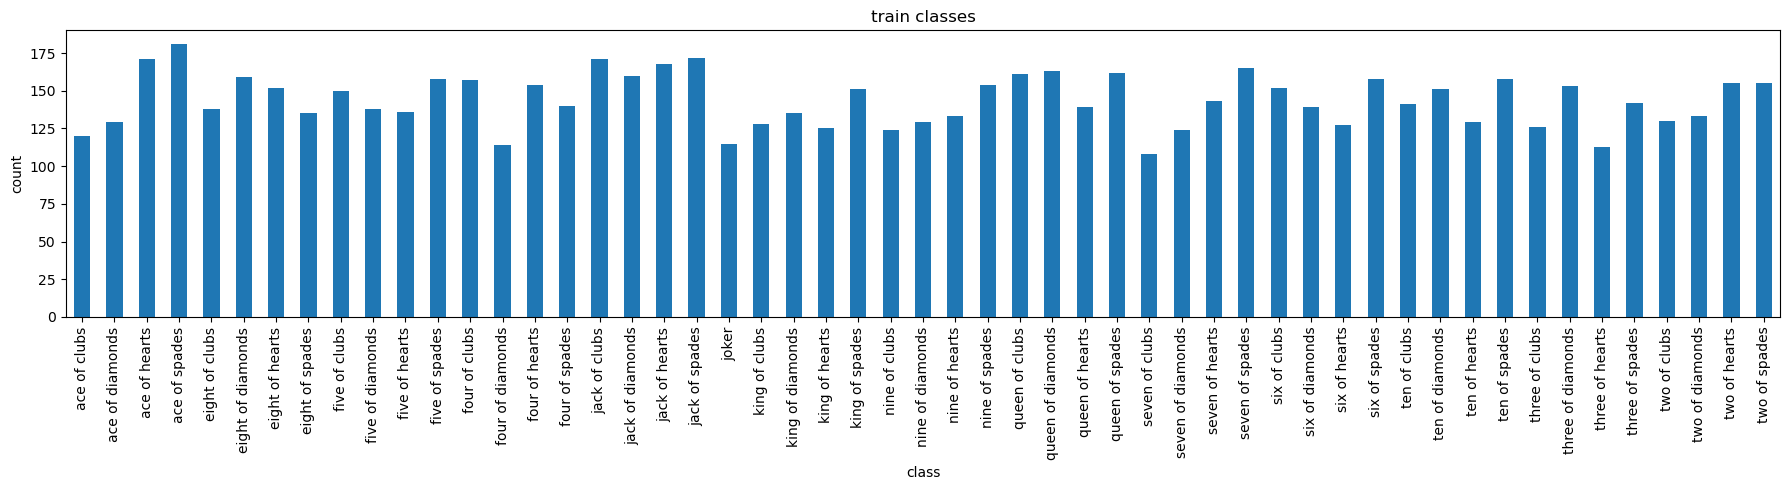

In [4]:
train_counts = train_df["label"].value_counts().sort_index()

print("min:", int(train_counts.min()))
print("max:", int(train_counts.max()))
print("mean:", round(float(train_counts.mean()), 2))

plt.figure(figsize=(18, 5))
train_counts.plot(kind="bar")
plt.xlabel("class")
plt.ylabel("count")
plt.title("train classes")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "train_classes.png", dpi=140, bbox_inches="tight")
plt.show()

## 5. Przykladowe obrazy

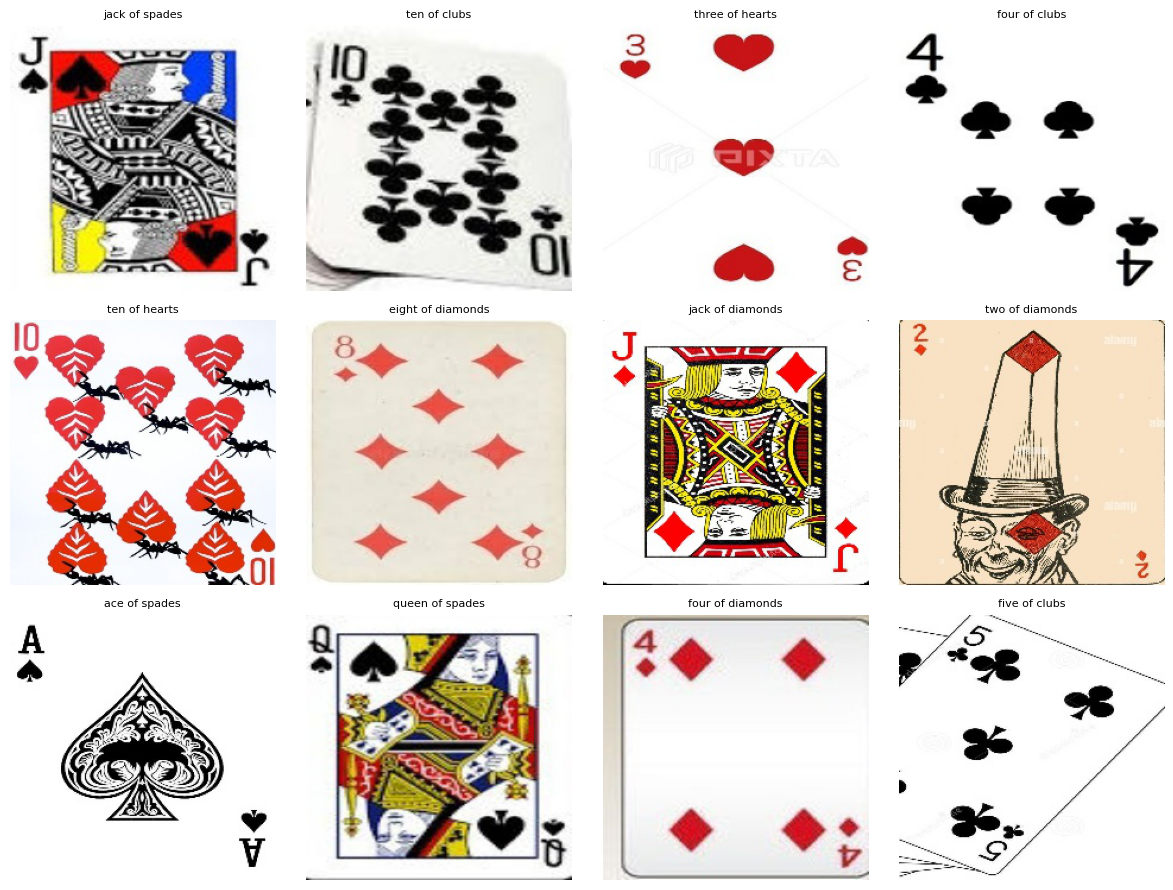

In [5]:
sample_labels = np.random.choice(class_names, size=min(12, len(class_names)), replace=False)

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
axes = axes.ravel()

for ax, label in zip(axes, sample_labels):
    sample_path = train_df.loc[train_df["label"] == label, "filepath"].sample(1, random_state=SEED).iloc[0]
    img = load_img(sample_path, target_size=IMG_SIZE)
    ax.imshow(img)
    ax.set_title(label, fontsize=8)
    ax.axis("off")

for i in range(len(sample_labels), len(axes)):
    axes[i].axis("off")

plt.tight_layout()
plt.savefig(PLOTS_DIR / "sample_images.png", dpi=140, bbox_inches="tight")
plt.show()

## 6. Podzial do szybkiego strojenia

Na etapie przeszukiwania architektur uzywamy mniejszej probki danych i mniejszej liczby epok.
To przyspiesza porownanie struktur i wartosci parametrów.

Na koncu wybrana konfiguracja jest trenowana ponownie na calym zbiorze treningowym.
Test pozostaje nietkniety do finalnej oceny.

In [6]:
def stratified_sample(df, frac, seed=SEED):
    frac = float(frac)
    if frac >= 0.999:
        return df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    sampled = (
        df.groupby("label", group_keys=False)
          .apply(lambda x: x.sample(max(1, int(np.ceil(len(x) * frac))), random_state=seed))
          .reset_index(drop=True)
    )
    return sampled

search_train_df = stratified_sample(train_df, 0.35)
search_valid_df = stratified_sample(valid_df, 0.60) if not valid_df.empty else valid_df.copy()

print("search train:", len(search_train_df))
print("search valid:", len(search_valid_df))

search train: 2694
search valid: 159


/tmp/ipykernel_1070/986790094.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(max(1, int(np.ceil(len(x) * frac))), random_state=seed))
/tmp/ipykernel_1070/986790094.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(max(1, int(np.ceil(len(x) * frac))), random_state=seed))


## 7. Generatory danych

In [7]:
def make_datagens(preprocess_fn=None, augment=False, raw_input=False):
    train_args = {}
    eval_args = {}
    if preprocess_fn is None:
        if not raw_input:
            train_args["rescale"] = 1.0 / 255.0
            eval_args["rescale"] = 1.0 / 255.0
    else:
        train_args["preprocessing_function"] = preprocess_fn
        eval_args["preprocessing_function"] = preprocess_fn

    if augment:
        train_args.update(
            rotation_range=15,
            width_shift_range=0.10,
            height_shift_range=0.10,
            zoom_range=0.10,
            shear_range=0.10,
            horizontal_flip=True,
            fill_mode="nearest",
        )

    return ImageDataGenerator(**train_args), ImageDataGenerator(**eval_args), ImageDataGenerator(**eval_args)

def make_generators(train_data, valid_data, test_data=None, batch_size=24, preprocess_fn=None, augment=False, raw_input=False):
    train_gen_obj, valid_gen_obj, test_gen_obj = make_datagens(preprocess_fn=preprocess_fn, augment=augment, raw_input=raw_input)

    train_gen = train_gen_obj.flow_from_dataframe(
        train_data,
        x_col="filepath",
        y_col="label",
        target_size=IMG_SIZE,
        class_mode="categorical",
        batch_size=batch_size,
        shuffle=True,
        seed=SEED,
    )

    valid_gen = None
    if valid_data is not None and len(valid_data) > 0:
        valid_gen = valid_gen_obj.flow_from_dataframe(
            valid_data,
            x_col="filepath",
            y_col="label",
            target_size=IMG_SIZE,
            class_mode="categorical",
            batch_size=batch_size,
            shuffle=False,
        )

    test_gen = None
    if test_data is not None and len(test_data) > 0:
        test_gen = test_gen_obj.flow_from_dataframe(
            test_data,
            x_col="filepath",
            y_col="label",
            target_size=IMG_SIZE,
            class_mode="categorical",
            batch_size=batch_size,
            shuffle=False,
        )

    return train_gen, valid_gen, test_gen

## 8. Podglad augmentacji

Found 2694 validated image filenames belonging to 53 classes.
Found 159 validated image filenames belonging to 53 classes.


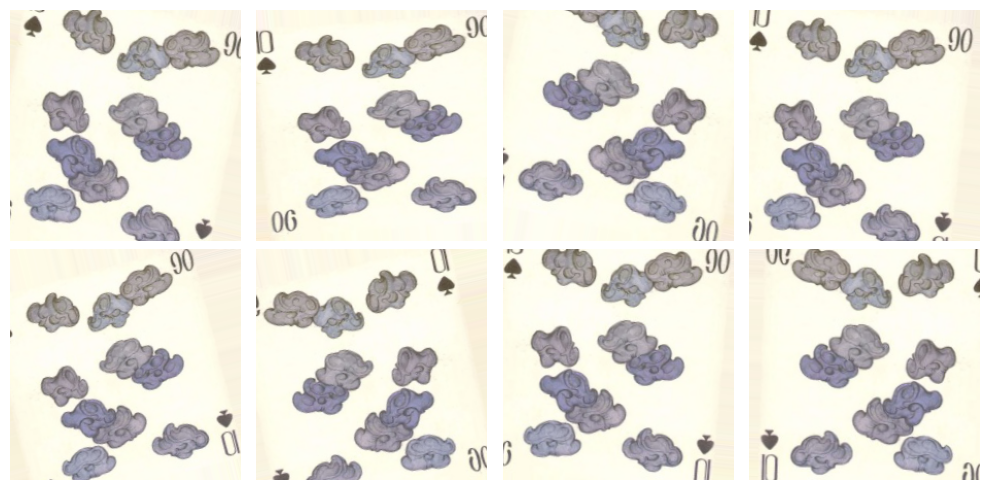

65

In [8]:
aug_train_gen, _, _ = make_generators(
    search_train_df,
    search_valid_df,
    None,
    batch_size=1,
    preprocess_fn=None,
    augment=True,
)

sample_path = search_train_df.sample(1, random_state=SEED)["filepath"].iloc[0]
sample_img = load_img(sample_path, target_size=IMG_SIZE)
sample_arr = np.expand_dims(img_to_array(sample_img), axis=0)

preview_gen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    rotation_range=15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    shear_range=0.10,
    horizontal_flip=True,
    fill_mode="nearest",
)

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
axes = axes.ravel()

for i, batch in enumerate(preview_gen.flow(sample_arr, batch_size=1, shuffle=False)):
    axes[i].imshow(batch[0])
    axes[i].axis("off")
    if i == 7:
        break

plt.tight_layout()
plt.savefig(PLOTS_DIR / "augmentation_preview.png", dpi=140, bbox_inches="tight")
plt.show()

del aug_train_gen
gc.collect()

## 9. Funkcje pomocnicze

In [9]:
def clear_memory():
    keras.backend.clear_session()
    gc.collect()

def make_callbacks(model_name, patience=4):
    return [
        ModelCheckpoint(
            filepath=str(CHECKPOINTS_DIR / f"{model_name}.keras"),
            monitor="val_accuracy",
            mode="max",
            save_best_only=True,
            verbose=1,
        ),
        EarlyStopping(
            monitor="val_loss",
            patience=patience,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=max(2, patience // 2),
            min_lr=1e-6,
            verbose=1,
        ),
        CSVLogger(str(LOGS_DIR / f"{model_name}.csv")),
    ]

def plot_history(history, title, save_name):
    hist_df = pd.DataFrame(history.history)
    hist_df["epoch"] = np.arange(1, len(hist_df) + 1)
    hist_df.to_csv(HISTORY_DIR / f"{save_name}.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].plot(hist_df["epoch"], hist_df["accuracy"], label="train")
    axes[0].plot(hist_df["epoch"], hist_df["val_accuracy"], label="valid")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("acc")
    axes[0].set_title("acc")
    axes[0].legend()

    axes[1].plot(hist_df["epoch"], hist_df["loss"], label="train")
    axes[1].plot(hist_df["epoch"], hist_df["val_loss"], label="valid")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("loss")
    axes[1].set_title("loss")
    axes[1].legend()

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"{save_name}.png", dpi=140, bbox_inches="tight")
    plt.show()

def evaluate_model(model, generator, model_name):
    loss, acc = model.evaluate(generator, verbose=0)
    print(f"{model_name}: acc={acc:.4f}, loss={loss:.4f}")
    return {"model": model_name, "accuracy": float(acc), "loss": float(loss)}

def load_saved_model(model_path):
    return keras.models.load_model(model_path)

## 10. Architektury CNN

In [10]:
def cnn_small(num_classes, dropout=0.30):
    model = keras.Sequential([
        layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
        layers.Conv2D(32, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, activation="relu", padding="same"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

def cnn_bn_gap(num_classes, dropout=0.35):
    model = keras.Sequential([
        layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
        layers.Conv2D(32, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.15),

        layers.Conv2D(64, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.20),

        layers.Conv2D(128, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.MaxPooling2D(),
        layers.Dropout(0.25),

        layers.Conv2D(192, 3, padding="same"),
        layers.BatchNormalization(),
        layers.Activation("relu"),
        layers.GlobalAveragePooling2D(),
        layers.Dense(192, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(num_classes, activation="softmax"),
    ])
    return model

def cnn_separable(num_classes, dropout=0.30):
    inputs = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    x = layers.Rescaling(1.0 / 255.0)(inputs)
    for filters in [32, 64, 128, 192]:
        x = layers.SeparableConv2D(filters, 3, padding="same", use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(192, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inputs, outputs, name="cnn_separable")

def residual_block(x, filters, stride=1):
    shortcut = x
    x = layers.Conv2D(filters, 3, strides=stride, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(filters, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)

    if shortcut.shape[-1] != filters or stride != 1:
        shortcut = layers.Conv2D(filters, 1, strides=stride, padding="same", use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x

def cnn_residual_light(num_classes, dropout=0.30):
    inputs = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    x = layers.Rescaling(1.0 / 255.0)(inputs)
    x = layers.Conv2D(32, 3, padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = residual_block(x, 32)
    x = layers.MaxPooling2D()(x)
    x = residual_block(x, 64)
    x = layers.MaxPooling2D()(x)
    x = residual_block(x, 128)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inputs, outputs, name="cnn_residual_light")

CNN_BUILDERS = {
    "cnn_small": cnn_small,
    "cnn_bn_gap": cnn_bn_gap,
    "cnn_separable": cnn_separable,
    "cnn_residual_light": cnn_residual_light,
}

## 11. Konfiguracje CNN

Sprawdzamy rozne struktury i parametry:
- klasyczny CNN
- CNN z BN i GAP
- separable CNN
- lekki CNN rezydualny
- rozne learning rate
- rozne dropout
- label smoothing

In [11]:
cnn_search_configs = [
    {"name": "cnn_small_lr1e3", "builder": "cnn_small", "lr": 1e-3, "dropout": 0.30, "label_smoothing": 0.00},
    {"name": "cnn_small_lr3e4", "builder": "cnn_small", "lr": 3e-4, "dropout": 0.35, "label_smoothing": 0.05},
    {"name": "cnn_bn_gap_lr1e3", "builder": "cnn_bn_gap", "lr": 1e-3, "dropout": 0.35, "label_smoothing": 0.05},
    {"name": "cnn_bn_gap_lr3e4", "builder": "cnn_bn_gap", "lr": 3e-4, "dropout": 0.40, "label_smoothing": 0.05},
    {"name": "cnn_separable_lr1e3", "builder": "cnn_separable", "lr": 1e-3, "dropout": 0.30, "label_smoothing": 0.05},
    {"name": "cnn_residual_lr3e4", "builder": "cnn_residual_light", "lr": 3e-4, "dropout": 0.30, "label_smoothing": 0.05},
]

pd.DataFrame(cnn_search_configs)

,name,builder,lr,dropout,label_smoothing
0,cnn_small_lr1e3,cnn_small,0.0010,0.30,0.00
1,cnn_small_lr3e4,cnn_small,0.0003,0.35,0.05
2,cnn_bn_gap_lr1e3,cnn_bn_gap,0.0010,0.35,0.05
3,cnn_bn_gap_lr3e4,cnn_bn_gap,0.0003,0.40,0.05
4,cnn_separable_lr1e3,cnn_separable,0.0010,0.30,0.05
5,cnn_residual_lr3e4,cnn_residual_light,0.0003,0.30,0.05


## 12. Strojenie CNN na mniejszej probce

Start: cnn_small_lr1e3
Found 2694 validated image filenames belonging to 53 classes.
Found 159 validated image filenames belonging to 53 classes.


I0000 00:00:1775250329.851323    1070 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5561 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:0a:00.0, compute capability: 8.9


Epoch 1/8


I0000 00:00:1775250331.740437    1070 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1775250333.437712    1160 service.cc:153] XLA service 0x77356c0061d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775250333.437851    1160 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1775250333.502255    1160 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1775250333.883990    1160 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1775250333.955612    1160 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2062__.44
I0000 00:00:1775250336.381004    1160 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set

  1/113 ━━━━━━━━━━━━━━━━━━━━ 29:30 16s/step - accuracy: 0.0000e+00 - loss: 3.9794

...

 87/113 ━━━━━━━━━━━━━━━━━━━━ 7s 296ms/step - accuracy: 0.0146 - loss: 4.0297

I0000 00:00:1775250373.307545    1159 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2062__.44


113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.0159 - loss: 4.0129

I0000 00:00:1775250391.695126    1161 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.



Epoch 1: val_accuracy improved from None to 0.05660, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/cnn_small_lr1e3.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 66s 452ms/step - accuracy: 0.0215 - loss: 3.9455 - val_accuracy: 0.0566 - val_loss: 3.7041 - learning_rate: 0.0010
Epoch 2/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.0717 - loss: 3.7627
Epoch 2: val_accuracy improved from 0.05660 to 0.22013, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/cnn_small_lr1e3.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 34s 299ms/step - accuracy: 0.0909 - loss: 3.6303 - val_accuracy: 0.2201 - val_loss: 2.8077 - learning_rate: 0.0010
Epoch 3/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step - accuracy: 0.1539 - loss: 3.2730
Epoch 3: val_accuracy improved from 0.22013 to 0.29560, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/cnn_small_lr1e3.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 33s 293ms/step - accuracy: 0.1578 - loss: 3.2004 - val_

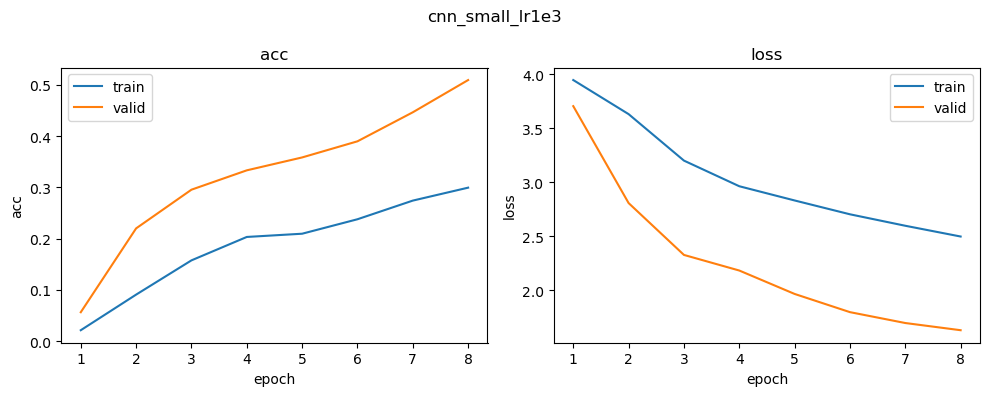

Start: cnn_small_lr3e4
Found 2694 validated image filenames belonging to 53 classes.
Found 159 validated image filenames belonging to 53 classes.
Epoch 1/8


I0000 00:00:1775250624.300149    1159 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_9357__.44


 43/113 ━━━━━━━━━━━━━━━━━━━━ 17s 255ms/step - accuracy: 0.0214 - loss: 4.0914

I0000 00:00:1775250638.897241    1161 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_9357__.44


113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 303ms/step - accuracy: 0.0242 - loss: 4.0305
Epoch 1: val_accuracy improved from None to 0.08176, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/cnn_small_lr3e4.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 43s 335ms/step - accuracy: 0.0267 - loss: 3.9748 - val_accuracy: 0.0818 - val_loss: 3.8281 - learning_rate: 3.0000e-04
Epoch 2/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step - accuracy: 0.0495 - loss: 3.8727
Epoch 2: val_accuracy improved from 0.08176 to 0.15094, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/cnn_small_lr3e4.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 30s 268ms/step - accuracy: 0.0583 - loss: 3.8150 - val_accuracy: 0.1509 - val_loss: 3.3233 - learning_rate: 3.0000e-04
Epoch 3/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.0955 - loss: 3.5961
Epoch 3: val_accuracy improved from 0.15094 to 0.19497, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/cnn_small_lr3e4.keras


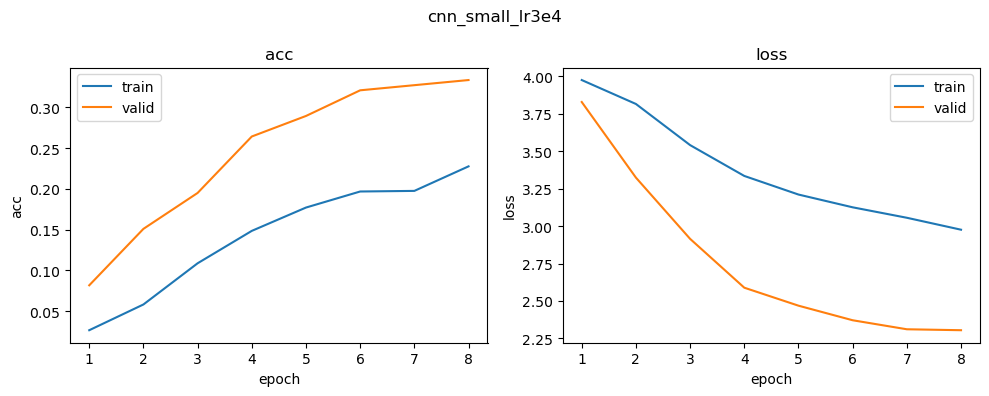

Start: cnn_bn_gap_lr1e3
Found 2694 validated image filenames belonging to 53 classes.
Found 159 validated image filenames belonging to 53 classes.
Epoch 1/8


I0000 00:00:1775250898.660308    1159 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_19026__.72
I0000 00:00:1775250899.205147    1159 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1775250900.746208    3070 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_1_6', 4 bytes spill stores, 4 bytes spill loads



 94/113 ━━━━━━━━━━━━━━━━━━━━ 4s 235ms/step - accuracy: 0.0325 - loss: 3.9740

I0000 00:00:1775250938.498355    1162 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_19026__.72
I0000 00:00:1775250949.313127    3238 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_3', 232 bytes spill stores, 232 bytes spill loads

I0000 00:00:1775250956.441804    1162 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_3', 240 bytes spill stores, 240 bytes spill loads



113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.0341 - loss: 3.9540

I0000 00:00:1775250960.867544    1159 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.



Epoch 1: val_accuracy improved from None to 0.02516, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/cnn_bn_gap_lr1e3.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 71s 449ms/step - accuracy: 0.0438 - loss: 3.8403 - val_accuracy: 0.0252 - val_loss: 4.1518 - learning_rate: 0.0010
Epoch 2/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.0685 - loss: 3.5874
Epoch 2: val_accuracy improved from 0.02516 to 0.04403, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/cnn_bn_gap_lr1e3.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 35s 312ms/step - accuracy: 0.0716 - loss: 3.5572 - val_accuracy: 0.0440 - val_loss: 4.3324 - learning_rate: 0.0010
Epoch 3/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - accuracy: 0.0731 - loss: 3.4444
Epoch 3: val_accuracy improved from 0.04403 to 0.05660, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/cnn_bn_gap_lr1e3.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 30s 262ms/step - accuracy: 0.0776 - loss: 3.4478 - v

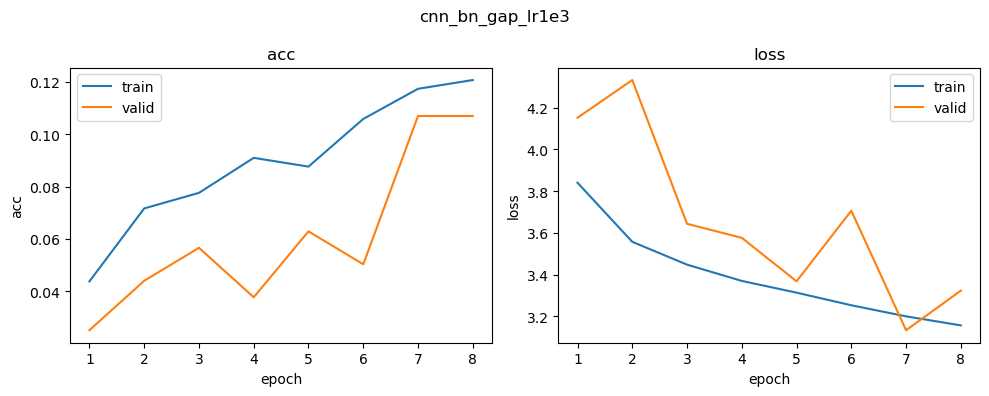

Start: cnn_bn_gap_lr3e4
Found 2694 validated image filenames belonging to 53 classes.
Found 159 validated image filenames belonging to 53 classes.
Epoch 1/8


I0000 00:00:1775251193.388984    1162 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_29216__.72


 91/113 ━━━━━━━━━━━━━━━━━━━━ 5s 255ms/step - accuracy: 0.0320 - loss: 3.9832

I0000 00:00:1775251224.688667    1162 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_29216__.72
I0000 00:00:1775251232.968814    1162 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'input_add_reduce_fusion_3', 240 bytes spill stores, 240 bytes spill loads



113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.0346 - loss: 3.9657
Epoch 1: val_accuracy improved from None to 0.01887, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/cnn_bn_gap_lr3e4.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 51s 360ms/step - accuracy: 0.0457 - loss: 3.8844 - val_accuracy: 0.0189 - val_loss: 4.0909 - learning_rate: 3.0000e-04
Epoch 2/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.0536 - loss: 3.7144
Epoch 2: val_accuracy improved from 0.01887 to 0.03774, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/cnn_bn_gap_lr3e4.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 36s 316ms/step - accuracy: 0.0598 - loss: 3.6805 - val_accuracy: 0.0377 - val_loss: 3.9772 - learning_rate: 3.0000e-04
Epoch 3/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.0706 - loss: 3.5847
Epoch 3: val_accuracy improved from 0.03774 to 0.07547, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/cnn_bn_gap_lr3e4.ker

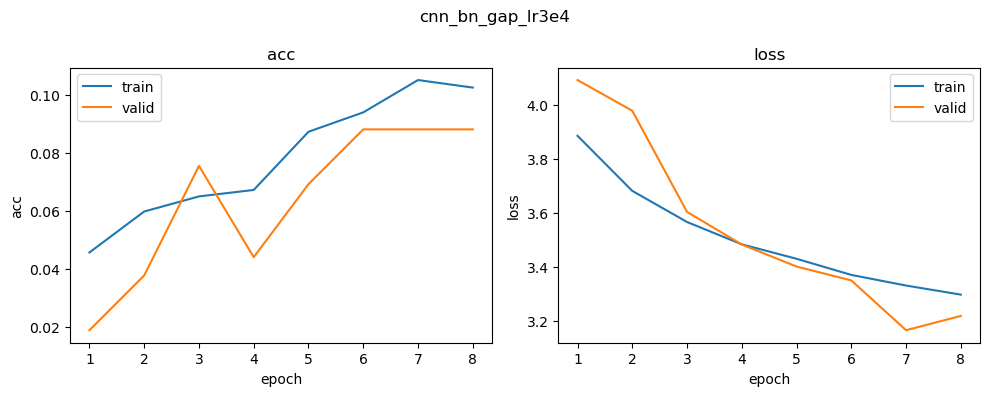

Start: cnn_separable_lr1e3
Found 2694 validated image filenames belonging to 53 classes.
Found 159 validated image filenames belonging to 53 classes.
Epoch 1/8


I0000 00:00:1775251473.624433    1161 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_39165__.75


 14/113 ━━━━━━━━━━━━━━━━━━━━ 22s 225ms/step - accuracy: 0.0239 - loss: 3.9695

I0000 00:00:1775251496.930929    1159 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_39165__.75


113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.0317 - loss: 3.9424
Epoch 1: val_accuracy improved from None to 0.01887, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/cnn_separable_lr1e3.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 76s 470ms/step - accuracy: 0.0382 - loss: 3.8824 - val_accuracy: 0.0189 - val_loss: 3.9713 - learning_rate: 0.0010
Epoch 2/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.0474 - loss: 3.6154
Epoch 2: val_accuracy did not improve from 0.01887
113/113 ━━━━━━━━━━━━━━━━━━━━ 33s 288ms/step - accuracy: 0.0542 - loss: 3.5569 - val_accuracy: 0.0189 - val_loss: 3.9945 - learning_rate: 0.0010
Epoch 3/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.0738 - loss: 3.4230
Epoch 3: val_accuracy did not improve from 0.01887

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
113/113 ━━━━━━━━━━━━━━━━━━━━ 30s 268ms/step - accuracy: 0.0794 - loss: 3.4129 - val_accuracy: 0.0189 - val_loss: 4.1450 - learnin

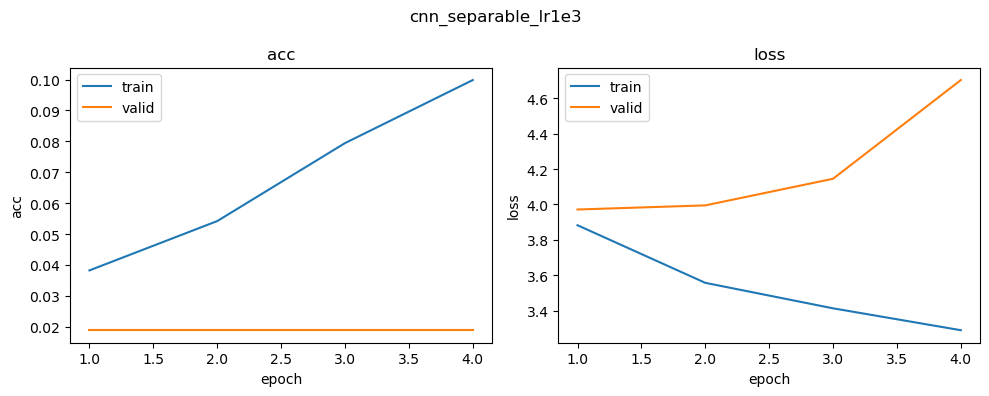

Start: cnn_residual_lr3e4
Found 2694 validated image filenames belonging to 53 classes.
Found 159 validated image filenames belonging to 53 classes.
Epoch 1/8


I0000 00:00:1775251651.504459    1161 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_48407__.88


 86/113 ━━━━━━━━━━━━━━━━━━━━ 7s 272ms/step - accuracy: 0.0295 - loss: 4.0750

I0000 00:00:1775251690.207789    1160 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_48407__.88


113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 370ms/step - accuracy: 0.0309 - loss: 4.0446

I0000 00:00:1775251708.472138    1159 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.



Epoch 1: val_accuracy improved from None to 0.01887, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/cnn_residual_lr3e4.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 72s 450ms/step - accuracy: 0.0367 - loss: 3.9290 - val_accuracy: 0.0189 - val_loss: 4.0875 - learning_rate: 3.0000e-04
Epoch 2/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.0567 - loss: 3.7395
Epoch 2: val_accuracy did not improve from 0.01887
113/113 ━━━━━━━━━━━━━━━━━━━━ 27s 231ms/step - accuracy: 0.0572 - loss: 3.7253 - val_accuracy: 0.0189 - val_loss: 4.1935 - learning_rate: 3.0000e-04
Epoch 3/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.0673 - loss: 3.6662
Epoch 3: val_accuracy did not improve from 0.01887

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
113/113 ━━━━━━━━━━━━━━━━━━━━ 31s 275ms/step - accuracy: 0.0687 - loss: 3.6351 - val_accuracy: 0.0189 - val_loss: 4.3204 - learning_rate: 3.0000e-04
Epoch 4/8
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/st

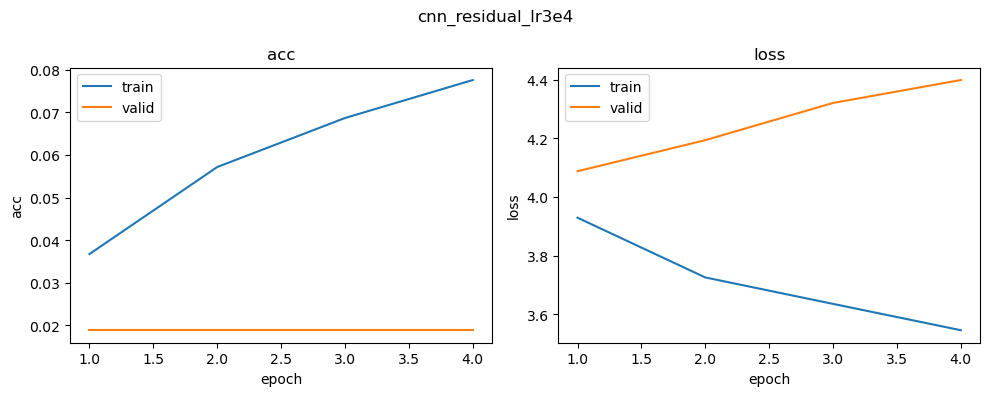

,name,builder,lr,dropout,label_smoothing,best_val_acc,best_epoch,val_loss_at_best,model_path
0,cnn_small_lr1e3,cnn_small,0.0010,0.30,0.00,0.509434,8,1.631786,/home/chemik/studia/ggsn/agh_ggsn/ex2/results/...
1,cnn_small_lr3e4,cnn_small,0.0003,0.35,0.05,0.333333,8,2.304614,/home/chemik/studia/ggsn/agh_ggsn/ex2/results/...
2,cnn_bn_gap_lr1e3,cnn_bn_gap,0.0010,0.35,0.05,0.106918,7,3.133596,/home/chemik/studia/ggsn/agh_ggsn/ex2/results/...
3,cnn_bn_gap_lr3e4,cnn_bn_gap,0.0003,0.40,0.05,0.088050,6,3.348766,/home/chemik/studia/ggsn/agh_ggsn/ex2/results/...
4,cnn_separable_lr1e3,cnn_separable,0.0010,0.30,0.05,0.018868,1,3.971254,/home/chemik/studia/ggsn/agh_ggsn/ex2/results/...
5,cnn_residual_lr3e4,cnn_residual_light,0.0003,0.30,0.05,0.018868,1,4.087513,/home/chemik/studia/ggsn/agh_ggsn/ex2/results/...


In [12]:
cnn_search_results = []

for cfg in cnn_search_configs:
    clear_memory()
    print("=" * 70)
    print("Start:", cfg["name"])
    print("=" * 70)

    train_gen, valid_gen, _ = make_generators(
        search_train_df,
        search_valid_df,
        None,
        batch_size=SEARCH_BATCH_SIZE,
        preprocess_fn=None,
        augment=True,
    )

    model = CNN_BUILDERS[cfg["builder"]](NUM_CLASSES, dropout=cfg["dropout"])
    loss_fn = keras.losses.CategoricalCrossentropy(label_smoothing=cfg["label_smoothing"])
    model.compile(
        optimizer=Adam(learning_rate=cfg["lr"]),
        loss=loss_fn,
        metrics=["accuracy"],
    )

    history = model.fit(
        train_gen,
        validation_data=valid_gen,
        epochs=SEARCH_EPOCHS,
        callbacks=make_callbacks(cfg["name"], patience=3),
        verbose=1,
    )

    plot_history(history, cfg["name"], cfg["name"])

    best_val_acc = float(np.max(history.history["val_accuracy"]))
    best_epoch = int(np.argmax(history.history["val_accuracy"]) + 1)
    final_val_loss = float(history.history["val_loss"][best_epoch - 1])

    cnn_search_results.append({
        "name": cfg["name"],
        "builder": cfg["builder"],
        "lr": cfg["lr"],
        "dropout": cfg["dropout"],
        "label_smoothing": cfg["label_smoothing"],
        "best_val_acc": best_val_acc,
        "best_epoch": best_epoch,
        "val_loss_at_best": final_val_loss,
        "model_path": str(CHECKPOINTS_DIR / f"{cfg['name']}.keras"),
    })

    del model, history, train_gen, valid_gen
    gc.collect()

cnn_search_df = pd.DataFrame(cnn_search_results).sort_values(["best_val_acc", "val_loss_at_best"], ascending=[False, True]).reset_index(drop=True)
cnn_search_df.to_csv(RESULTS_DIR / "cnn_search_summary.csv", index=False)
cnn_search_df

## 13. Porownanie CNN

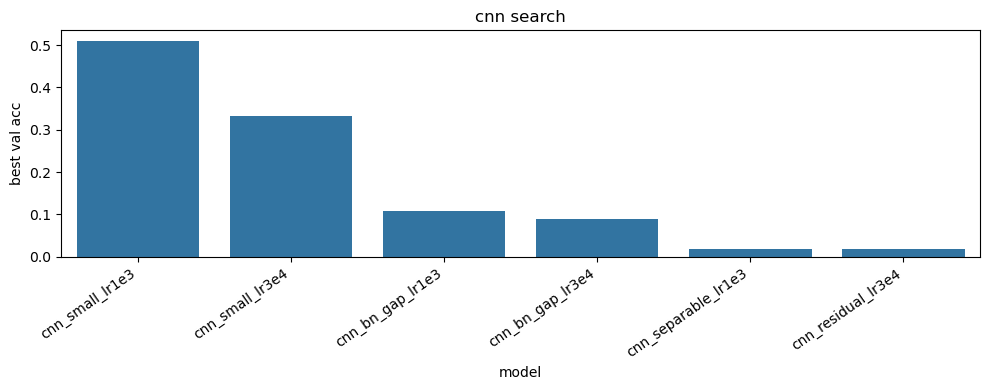

best cnn config:
{'name': 'cnn_small_lr1e3', 'builder': 'cnn_small', 'lr': 0.001, 'dropout': 0.3, 'label_smoothing': 0.0, 'best_val_acc': 0.5094339847564697, 'best_epoch': 8, 'val_loss_at_best': 1.6317856311798096, 'model_path': '/home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/cnn_small_lr1e3.keras'}


In [13]:
plt.figure(figsize=(10, 4))
sns.barplot(data=cnn_search_df, x="name", y="best_val_acc")
plt.xticks(rotation=35, ha="right")
plt.xlabel("model")
plt.ylabel("best val acc")
plt.title("cnn search")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "cnn_search_bar.png", dpi=140, bbox_inches="tight")
plt.show()

best_cnn_cfg = cnn_search_df.iloc[0].to_dict()
print("best cnn config:")
print(best_cnn_cfg)

## 14. Finalny trening najlepszego CNN

Tutaj bierzemy najlepsza konfiguracje z poprzedniego kroku
i trenujemy ja od nowa na pelnym zbiorze treningowym.

Found 7624 validated image filenames belonging to 53 classes.
Found 265 validated image filenames belonging to 53 classes.
Epoch 1/20


I0000 00:00:1775251813.898472    1159 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_53683__.44


158/318 ━━━━━━━━━━━━━━━━━━━━ 41s 262ms/step - accuracy: 0.0316 - loss: 4.1611

I0000 00:00:1775251859.987427    1160 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_53683__.44


318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - accuracy: 0.0631 - loss: 3.8732
Epoch 1: val_accuracy improved from None to 0.33585, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/best_cnn_full.keras
318/318 ━━━━━━━━━━━━━━━━━━━━ 106s 315ms/step - accuracy: 0.1201 - loss: 3.4289 - val_accuracy: 0.3358 - val_loss: 2.1672 - learning_rate: 0.0010
Epoch 2/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.2252 - loss: 2.7847
Epoch 2: val_accuracy improved from 0.33585 to 0.44151, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/best_cnn_full.keras
318/318 ━━━━━━━━━━━━━━━━━━━━ 89s 278ms/step - accuracy: 0.2462 - loss: 2.7116 - val_accuracy: 0.4415 - val_loss: 1.7549 - learning_rate: 0.0010
Epoch 3/20
318/318 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - accuracy: 0.3067 - loss: 2.5137
Epoch 3: val_accuracy improved from 0.44151 to 0.52075, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/best_cnn_full.keras
318/318 ━━━

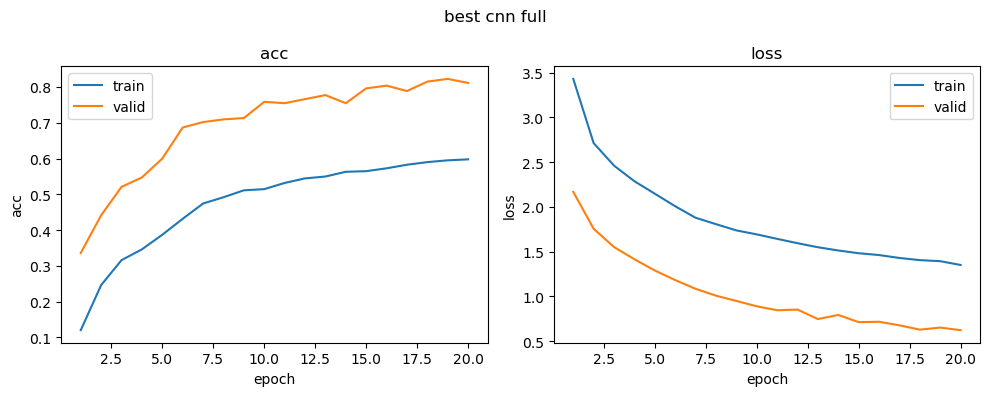

In [14]:
clear_memory()

full_train_gen, full_valid_gen, _ = make_generators(
    train_df,
    valid_df,
    None,
    batch_size=FINAL_BATCH_SIZE,
    preprocess_fn=None,
    augment=True,
)

best_cnn_model = CNN_BUILDERS[best_cnn_cfg["builder"]](NUM_CLASSES, dropout=float(best_cnn_cfg["dropout"]))
best_cnn_loss = keras.losses.CategoricalCrossentropy(label_smoothing=float(best_cnn_cfg["label_smoothing"]))
best_cnn_model.compile(
    optimizer=Adam(learning_rate=float(best_cnn_cfg["lr"])),
    loss=best_cnn_loss,
    metrics=["accuracy"],
)

best_cnn_history = best_cnn_model.fit(
    full_train_gen,
    validation_data=full_valid_gen,
    epochs=FINAL_EPOCHS,
    callbacks=make_callbacks("best_cnn_full", patience=5),
    verbose=1,
)

plot_history(best_cnn_history, "best cnn full", "best_cnn_full")
best_cnn_model.save(CHECKPOINTS_DIR / "best_cnn_full_last.keras")

## 15. Transfer learning

Modele sa trenowane pojedynczo.
Kazdy model ma wlasny preprocessing wejscia.
Nie trzymamy wszystkich modeli jednoczesnie w pamieci.

In [15]:
def get_preprocess_and_base(model_name):
    if model_name == "VGG16":
        from tensorflow.keras.applications.vgg16 import preprocess_input
        return preprocess_input, VGG16
    if model_name == "ResNet50":
        from tensorflow.keras.applications.resnet50 import preprocess_input
        return preprocess_input, ResNet50
    if model_name == "MobileNetV2":
        from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
        return preprocess_input, MobileNetV2
    if model_name == "EfficientNetB0":
        from tensorflow.keras.applications.efficientnet import preprocess_input
        return preprocess_input, EfficientNetB0
    raise ValueError(model_name)

def build_transfer_model(model_name, num_classes, dense_units=256, dropout=0.30, trainable_layers=20):
    preprocess_fn, base_class = get_preprocess_and_base(model_name)
    base_model = base_class(
        weights="imagenet",
        include_top=False,
        input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS),
    )
    base_model.trainable = True

    if trainable_layers <= 0:
        for layer in base_model.layers:
            layer.trainable = False
    else:
        for layer in base_model.layers[:-trainable_layers]:
            layer.trainable = False
        for layer in base_model.layers[-trainable_layers:]:
            layer.trainable = True

    inputs = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    x = preprocess_fn(inputs)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs, name=f"tl_{model_name}")
    return model, preprocess_fn

transfer_configs = [
    {"name": "VGG16", "trainable_layers": 4, "lr": 3e-4, "dropout": 0.30, "dense_units": 256},
    {"name": "ResNet50", "trainable_layers": 10, "lr": 1e-4, "dropout": 0.30, "dense_units": 256},
    {"name": "MobileNetV2", "trainable_layers": 20, "lr": 3e-4, "dropout": 0.25, "dense_units": 192},
    {"name": "EfficientNetB0", "trainable_layers": 20, "lr": 1e-4, "dropout": 0.25, "dense_units": 192},
]

pd.DataFrame(transfer_configs)

,name,trainable_layers,lr,dropout,dense_units
0,VGG16,4,0.0003,0.30,256
1,ResNet50,10,0.0001,0.30,256
2,MobileNetV2,20,0.0003,0.25,192
3,EfficientNetB0,20,0.0001,0.25,192


## 16. Trening modeli transfer learning

Start: VGG16
Found 7624 validated image filenames belonging to 53 classes.
Found 265 validated image filenames belonging to 53 classes.
Epoch 1/10


I0000 00:00:1775253524.321422    1162 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_85564__.72
W0000 00:00:1775253526.046119    1162 bfc_allocator.cc:383] Garbage collection: deallocate free memory regions (i.e., allocations) so that we can re-allocate a larger region to avoid OOM due to memory fragmentation. If you see this message frequently, you are running near the threshold of the available device memory and re-allocation may incur great performance overhead. You may try smaller batch sizes to observe the performance impact. Set TF_ENABLE_GPU_GARBAGE_COLLECTION=false if you'd like to disable this feature.


149/477 ━━━━━━━━━━━━━━━━━━━━ 54s 168ms/step - accuracy: 0.0155 - loss: 4.3879

I0000 00:00:1775253563.273067    1159 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_85564__.72


477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.0192 - loss: 4.1319
Epoch 1: val_accuracy improved from None to 0.01887, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/tl_VGG16.keras
477/477 ━━━━━━━━━━━━━━━━━━━━ 120s 218ms/step - accuracy: 0.0207 - loss: 3.9969 - val_accuracy: 0.0189 - val_loss: 3.9704 - learning_rate: 3.0000e-04
Epoch 2/10
477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.0239 - loss: 3.9687
Epoch 2: val_accuracy did not improve from 0.01887
477/477 ━━━━━━━━━━━━━━━━━━━━ 91s 190ms/step - accuracy: 0.0223 - loss: 3.9685 - val_accuracy: 0.0189 - val_loss: 3.9707 - learning_rate: 3.0000e-04
Epoch 3/10
477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.0212 - loss: 3.9673
Epoch 3: val_accuracy did not improve from 0.01887

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
477/477 ━━━━━━━━━━━━━━━━━━━━ 80s 168ms/step - accuracy: 0.0224 - loss: 3.9674 - val_accuracy: 0.0189 - val_loss: 3.9711 - learnin

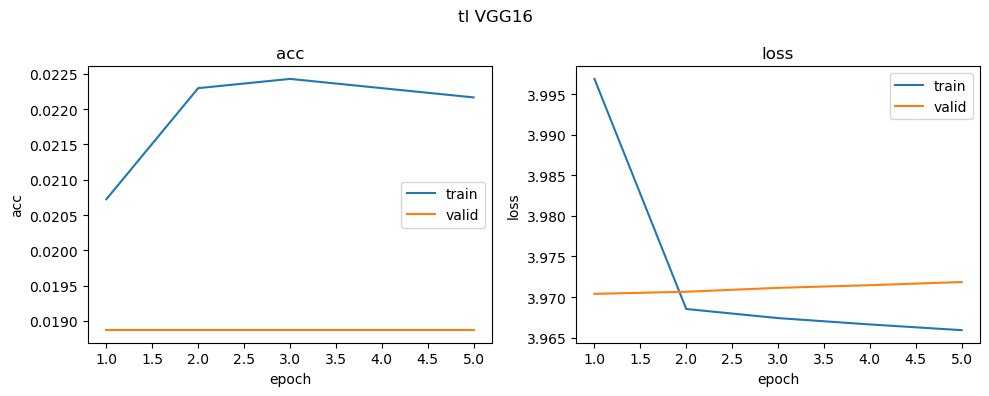

Start: ResNet50
Found 7624 validated image filenames belonging to 53 classes.
Found 265 validated image filenames belonging to 53 classes.
Epoch 1/10


I0000 00:00:1775253997.799466    1161 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_109402__.199


365/477 ━━━━━━━━━━━━━━━━━━━━ 17s 157ms/step - accuracy: 0.0850 - loss: 3.9621

I0000 00:00:1775254073.942910    1159 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_109402__.199


477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.1030 - loss: 3.8108
Epoch 1: val_accuracy improved from None to 0.39245, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/tl_ResNet50.keras
477/477 ━━━━━━━━━━━━━━━━━━━━ 133s 225ms/step - accuracy: 0.1724 - loss: 3.2394 - val_accuracy: 0.3925 - val_loss: 1.9850 - learning_rate: 1.0000e-04
Epoch 2/10
477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - accuracy: 0.3211 - loss: 2.3666
Epoch 2: val_accuracy improved from 0.39245 to 0.48302, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/tl_ResNet50.keras
477/477 ━━━━━━━━━━━━━━━━━━━━ 98s 205ms/step - accuracy: 0.3578 - loss: 2.2505 - val_accuracy: 0.4830 - val_loss: 1.5270 - learning_rate: 1.0000e-04
Epoch 3/10
477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - accuracy: 0.4593 - loss: 1.8518
Epoch 3: val_accuracy improved from 0.48302 to 0.56981, saving model to /home/chemik/studia/ggsn/agh_ggsn/ex2/results/checkpoints/tl_ResNet50.keras
477/477 ━

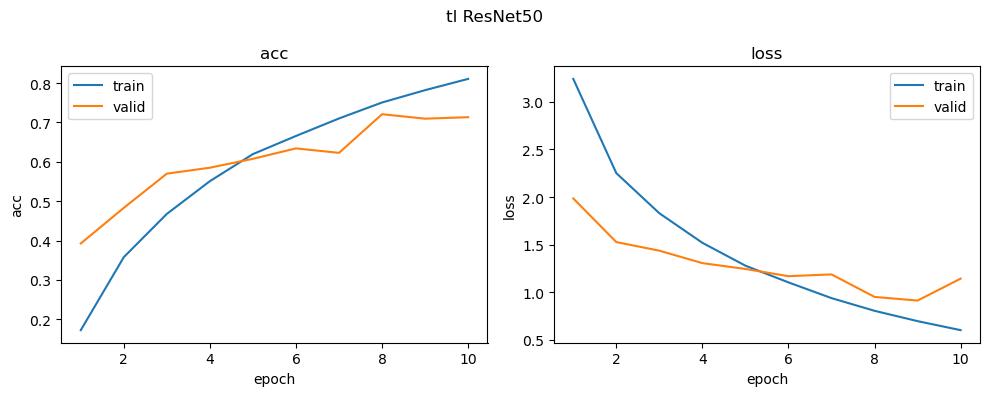

Start: MobileNetV2
Found 7624 validated image filenames belonging to 53 classes.
Found 265 validated image filenames belonging to 53 classes.
Epoch 1/10


I0000 00:00:1775254895.274412    1161 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_155640__.152
E0000 00:00:1775254900.629634    1161 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


174/477 ━━━━━━━━━━━━━━━━━━━━ 46s 153ms/step - accuracy: 0.0951 - loss: 3.7341

I0000 00:00:1775254956.630885    1159 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_155640__.152
E0000 00:00:1775254965.820985    1159 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.1674 - loss: 3.2717

E0000 00:00:1775255046.355385    1161 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


KeyboardInterrupt: 

In [16]:
transfer_results = []

for cfg in transfer_configs:
    clear_memory()
    print("=" * 70)
    print("Start:", cfg["name"])
    print("=" * 70)

    train_gen, valid_gen, _ = make_generators(
        train_df,
        valid_df,
        None,
        batch_size=TRANSFER_BATCH_SIZE,
        preprocess_fn=None,
        augment=True,
        raw_input=True,
    )

    model, _ = build_transfer_model(
        cfg["name"],
        NUM_CLASSES,
        dense_units=cfg["dense_units"],
        dropout=cfg["dropout"],
        trainable_layers=cfg["trainable_layers"],
    )

    model.compile(
        optimizer=Adam(learning_rate=cfg["lr"]),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    history = model.fit(
        train_gen,
        validation_data=valid_gen,
        epochs=TRANSFER_EPOCHS,
        callbacks=make_callbacks(f"tl_{cfg['name']}", patience=4),
        verbose=1,
    )

    plot_history(history, f"tl {cfg['name']}", f"tl_{cfg['name']}")

    transfer_results.append({
        "name": cfg["name"],
        "best_val_acc": float(np.max(history.history["val_accuracy"])),
        "best_epoch": int(np.argmax(history.history["val_accuracy"]) + 1),
        "model_path": str(CHECKPOINTS_DIR / f"tl_{cfg['name']}.keras"),
    })

    del model, history, train_gen, valid_gen
    gc.collect()

transfer_df = pd.DataFrame(transfer_results).sort_values("best_val_acc", ascending=False).reset_index(drop=True)
transfer_df.to_csv(RESULTS_DIR / "transfer_summary.csv", index=False)
transfer_df

## 17. Zbiorcze porownanie

In [ ]:
all_model_rows = []

all_model_rows.append({
    "group": "cnn",
    "name": "best_cnn_full",
    "best_val_acc": float(np.max(best_cnn_history.history["val_accuracy"])),
    "model_path": str(CHECKPOINTS_DIR / "best_cnn_full.keras"),
})

for _, row in transfer_df.iterrows():
    all_model_rows.append({
        "group": "transfer",
        "name": row["name"],
        "best_val_acc": float(row["best_val_acc"]),
        "model_path": row["model_path"],
    })

all_models_df = pd.DataFrame(all_model_rows).sort_values("best_val_acc", ascending=False).reset_index(drop=True)
all_models_df.to_csv(RESULTS_DIR / "all_models_summary.csv", index=False)
all_models_df

## 18. Ewaluacja na test

In [ ]:
test_results = []

# final cnn
clear_memory()
_, _, cnn_test_gen = make_generators(
    train_df.iloc[:1],
    valid_df.iloc[:1] if not valid_df.empty else valid_df,
    test_df,
    batch_size=FINAL_BATCH_SIZE,
    preprocess_fn=None,
    augment=False,
)
cnn_model = load_saved_model(CHECKPOINTS_DIR / "best_cnn_full.keras")
test_results.append(evaluate_model(cnn_model, cnn_test_gen, "best_cnn_full"))
del cnn_model, cnn_test_gen
gc.collect()

# transfer models
for _, row in transfer_df.iterrows():
    clear_memory()
    _, _, test_gen = make_generators(
        train_df.iloc[:1],
        valid_df.iloc[:1] if not valid_df.empty else valid_df,
        test_df,
        batch_size=TRANSFER_BATCH_SIZE,
        preprocess_fn=None,
        augment=False,
        raw_input=True,
    )
    model = load_saved_model(row["model_path"])
    test_results.append(evaluate_model(model, test_gen, row["name"]))
    del model, test_gen
    gc.collect()

test_df_results = pd.DataFrame(test_results).sort_values("accuracy", ascending=False).reset_index(drop=True)
test_df_results.to_csv(RESULTS_DIR / "test_results.csv", index=False)
test_df_results

## 19. Wykres test

In [ ]:
plt.figure(figsize=(8, 4))
sns.barplot(data=test_df_results, x="model", y="accuracy")
plt.xticks(rotation=35, ha="right")
plt.xlabel("model")
plt.ylabel("test acc")
plt.title("test")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "test_results.png", dpi=140, bbox_inches="tight")
plt.show()

best_overall_name = test_df_results.iloc[0]["model"]
print("best overall:", best_overall_name)

## 20. Najlepszy model do dalszej analizy

In [ ]:
def resolve_model_for_analysis(model_name):
    if model_name == "best_cnn_full":
        model = load_saved_model(CHECKPOINTS_DIR / "best_cnn_full.keras")
        preprocess_fn = None
        return model, preprocess_fn

    model = load_saved_model(CHECKPOINTS_DIR / f"tl_{model_name}.keras")
    preprocess_fn = None
    return model, preprocess_fn

analysis_model, analysis_preprocess = resolve_model_for_analysis(best_overall_name)
print("loaded:", best_overall_name)

## 21. Confusion matrix

In [ ]:
_, _, analysis_test_gen = make_generators(
    train_df.iloc[:1],
    valid_df.iloc[:1] if not valid_df.empty else valid_df,
    test_df,
    batch_size=FINAL_BATCH_SIZE if best_overall_name == "best_cnn_full" else TRANSFER_BATCH_SIZE,
    preprocess_fn=analysis_preprocess,
    augment=False,
    raw_input=(best_overall_name != "best_cnn_full"),
)

predictions = analysis_model.predict(analysis_test_gen, verbose=0)
y_pred = np.argmax(predictions, axis=1)
y_true = analysis_test_gen.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap="Blues", cbar=True)
plt.xlabel("pred")
plt.ylabel("true")
plt.title("cm")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "confusion_matrix_best.png", dpi=140, bbox_inches="tight")
plt.show()

print(classification_report(y_true, y_pred, target_names=list(analysis_test_gen.class_indices.keys()), zero_division=0))

## 22. Filtry CNN

In [ ]:
def visualize_filters(model, save_name, n_filters=16):
    conv_layers = [layer for layer in model.layers if isinstance(layer, layers.Conv2D)]
    if not conv_layers:
        print("Brak prostych warstw Conv2D w tym modelu")
        return

    kernel = conv_layers[0].get_weights()[0]
    kernel = (kernel - kernel.min()) / (kernel.max() - kernel.min() + 1e-8)

    n_filters = min(n_filters, kernel.shape[-1])
    fig, axes = plt.subplots(2, int(np.ceil(n_filters / 2)), figsize=(12, 4))
    axes = np.array(axes).ravel()

    for i in range(n_filters):
        filt = kernel[:, :, :, i]
        if filt.shape[-1] == 3:
            axes[i].imshow(filt)
        else:
            axes[i].imshow(filt[:, :, 0], cmap="gray")
        axes[i].axis("off")
        axes[i].set_title(f"f{i}", fontsize=8)

    for i in range(n_filters, len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"{save_name}_filters.png", dpi=140, bbox_inches="tight")
    plt.show()

if best_overall_name == "best_cnn_full":
    visualize_filters(analysis_model, "best_cnn", n_filters=16)
else:
    print("Filtry zostawiamy tylko dla CNN od zera")

## 23. Aktywacje

In [ ]:
def preprocess_single_image(img_path, preprocess_fn=None):
    img = load_img(img_path, target_size=IMG_SIZE)
    arr = img_to_array(img)
    arr = np.expand_dims(arr, axis=0)
    if preprocess_fn is None:
        arr = arr / 255.0
    else:
        arr = preprocess_fn(arr.copy())
    return img, arr

def get_first_conv_names(model, max_layers=6):
    names = []
    for layer in model.layers:
        if isinstance(layer, keras.Model):
            for sub in layer.layers:
                if isinstance(sub, (layers.Conv2D, layers.SeparableConv2D, layers.DepthwiseConv2D)):
                    names.append(sub.name)
        elif isinstance(layer, (layers.Conv2D, layers.SeparableConv2D, layers.DepthwiseConv2D)):
            names.append(layer.name)
    return names[:max_layers]

def find_nested_layer(model, layer_name):
    for layer in model.layers:
        if layer.name == layer_name:
            return layer
        if isinstance(layer, keras.Model):
            try:
                return layer.get_layer(layer_name)
            except Exception:
                pass
    raise ValueError(layer_name)

sample_analysis_path = test_df.sample(1, random_state=SEED)["filepath"].iloc[0]
print(sample_analysis_path)

conv_names = get_first_conv_names(analysis_model, max_layers=4)
if not conv_names:
    print("Brak warstw konwolucyjnych")
else:
    img, arr = preprocess_single_image(sample_analysis_path, analysis_preprocess)
    outputs = [find_nested_layer(analysis_model, name).output for name in conv_names]
    activation_model = Model(inputs=analysis_model.input, outputs=outputs)
    acts = activation_model.predict(arr, verbose=0)

    fig, axes = plt.subplots(1, len(acts), figsize=(4 * len(acts), 4))
    if len(acts) == 1:
        axes = [axes]

    for ax, name, act in zip(axes, conv_names, acts):
        ax.imshow(np.mean(act[0], axis=-1), cmap="viridis")
        ax.axis("off")
        ax.set_title(name, fontsize=8)

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "activations.png", dpi=140, bbox_inches="tight")
    plt.show()

## 24. Grad-CAM

In [ ]:
def get_last_conv_name(model):
    names = get_first_conv_names(model, max_layers=999)
    return names[-1] if names else None

def make_gradcam_heatmap(model, img_array, last_conv_name):
    target_layer = find_nested_layer(model, last_conv_name)
    grad_model = Model(
        inputs=model.inputs,
        outputs=[target_layer.output, model.output],
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array, training=False)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index.numpy()), float(predictions[0][pred_index].numpy())

img, arr = preprocess_single_image(sample_analysis_path, analysis_preprocess)
last_conv_name = get_last_conv_name(analysis_model)
print("last conv:", last_conv_name)

if last_conv_name is not None:
    heatmap, pred_idx, pred_score = make_gradcam_heatmap(analysis_model, arr, last_conv_name)
    heatmap_resized = cv2.resize(heatmap, (IMG_WIDTH, IMG_HEIGHT))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_rgb = cv2.cvtColor(cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET), cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(np.array(img).astype(np.uint8), 0.6, heatmap_rgb, 0.4, 0)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img)
    axes[0].axis("off")
    axes[0].set_title("img")

    axes[1].imshow(heatmap_rgb)
    axes[1].axis("off")
    axes[1].set_title("cam")

    axes[2].imshow(overlay)
    axes[2].axis("off")
    axes[2].set_title(f"{idx_to_class[pred_idx]} {pred_score:.2f}")

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "gradcam.png", dpi=140, bbox_inches="tight")
    plt.show()

## 25. Bledne predykcje

In [ ]:
mis_idx = np.where(y_pred != y_true)[0]
print("misclassified:", len(mis_idx), "/", len(y_true))

if len(mis_idx) > 0:
    show_idx = np.random.choice(mis_idx, size=min(12, len(mis_idx)), replace=False)
    fig, axes = plt.subplots(3, 4, figsize=(12, 9))
    axes = axes.ravel()

    for ax, idx in zip(axes, show_idx):
        img_path = analysis_test_gen.filepaths[idx]
        img = load_img(img_path, target_size=IMG_SIZE)
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(
            f"t:{idx_to_class[y_true[idx]]}\np:{idx_to_class[y_pred[idx]]}\n{predictions[idx][y_pred[idx]]:.2f}",
            fontsize=8,
            color="red",
        )

    for i in range(len(show_idx), len(axes)):
        axes[i].axis("off")

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "misclassified.png", dpi=140, bbox_inches="tight")
    plt.show()

## 26. Krotkie wnioski

In [ ]:
best_cnn_val = float(np.max(best_cnn_history.history["val_accuracy"]))
best_transfer_row = transfer_df.iloc[0] if not transfer_df.empty else None
best_transfer_text = (
    f"{best_transfer_row['name']} val={best_transfer_row['best_val_acc']:.4f}"
    if best_transfer_row is not None
    else "brak"
)

print("Najwazniejsze obserwacje:")
print(f"1. Szukanie architektury na probce ma sens, bo pozwala szybko odrzucic slabe CNN i zostawic najlepszy uklad do pelnego treningu.")
print(f"2. Najlepszy CNN po pelnym treningu uzyskal val={best_cnn_val:.4f}.")
print(f"3. Najlepszy transfer learning: {best_transfer_text}.")
print("4. Test byl uzyty dopiero na koncu.")
print("5. Dla 8 GB VRAM bezpieczne sa lekkie modele i trening pojedynczo.")

## 27. Koniec

In [ ]:
del analysis_model
del analysis_test_gen
gc.collect()

print("Done")
print("Results:", RESULTS_DIR)